In [1]:
from deepagents import create_deep_agent
from langchain.messages import HumanMessage, AIMessage, SystemMessage

### 大模型接口

In [2]:
# openai接口
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="qwen3.5-plus",             # 模型名称
    openai_api_key="sk-bvOWJIfQ8Y8IrZhzzpQZ80zSKHjWIHCkPXEgQ0H4Li5UCpUC",         # API Key
    openai_api_base="http://ai.wenmodel.com/v1", # API 地址 https://ai.wenmodel.com(https://m.tb.cn/h.ioaPOiq?tk=QGsd5gSbXZ)
    temperature=0.7,
    max_tokens=4096
)

response = llm.invoke("你是谁")
print(response.content)

你好！我是 **Qwen3.5**，是通义千问系列中最新推出的超大规模语言模型。我能够协助你完成各种任务，例如：

- **精准回答问题**：无论是学术问题、生活常识还是专业领域知识，我都能提供准确解答。
- **深度内容创作**：撰写故事、公文、邮件、剧本等，支持多轮对话与内容续写。
- **逻辑与代码专家**：解决数学问题、生成可运行代码（Python/JS 等），甚至调试复杂程序。
- **多语言无障碍**：支持全球 100+ 语言流畅交互，包括中文、英语、小语种等。
- **长文档理解**：轻松处理数十万字的文档或长视频内容，精准提取关键信息。
- **智能体自主规划**：可独立制定多步骤任务计划，调用工具完成复杂操作（如数据分析、网页搜索）。

有什么需要帮助的？随时告诉我！ 😊✨


### 消息构造函数

In [3]:
import os
from langchain.messages import HumanMessage

# 压缩并编码图片
def encode_image(path, max_kb=300):
    from io import BytesIO
    from PIL import Image
    import base64

    image = Image.open(path).convert("RGB")
    while True:
        for quality in range(90, 10, -5):
            buffer = BytesIO()
            image.save(buffer, "JPEG", quality=quality, optimize=True)

            if buffer.tell() <= max_kb * 1024:
                return base64.b64encode(buffer.getvalue()).decode()

        image.thumbnail((int(image.width * 0.8), int(image.height * 0.8)))


#下载网络图片
def download_image(url, save_path=None):
    # 请求图片
    response = requests.get(
        url,
        timeout=30,
        verify=False,
        headers={
            "User-Agent": "Mozilla/5.0"
        }
    )
    response.raise_for_status()
    # 如果没有指定保存路径，则根据URL自动生成文件名
    if save_path is None:
        filename = os.path.basename(urlparse(url).path)
        # URL没有文件名时
        if not filename:
            filename = "download_image.jpg"
        save_path = filename
    # 创建目录
    folder = os.path.dirname(save_path)
    if folder and not os.path.exists(folder):
        os.makedirs(folder)
    # 写入文件
    with open(save_path, "wb") as f:
        f.write(response.content)
    return save_path


# 构造消息
def build_msg(text=None, image_path=None):
    content = []
    # 添加文本
    if text:
        content.append({
            "type": "text",
            "text": text
        })

    # 添加图片
    if image_path:
        image_data = encode_image(image_path)

        content.append({
            "type": "image_url",
            "image_url": {
                "url": f"data:image/jpeg;base64,{image_data}",
                "detail": "auto"
            }
        })

    return [
        HumanMessage(content=content)
    ]

### 消息输出函数

In [4]:
def chat_stream(agent, model, message, config=None, subgraphs=True):
    messages = message if isinstance(message, list) else [message]
    content = messages[0].content
    has_image = isinstance(content, list) and any(x.get("type") == "image_url" for x in content)
    text = "".join(x.get("text", "") for x in content if x.get("type") == "text") if isinstance(content, list) else content

    # 处理图像
    if has_image and text:
        answer = ""
        for chunk in model.stream(messages):
            if chunk.content:
                answer += chunk.content
                print(chunk.content, end="", flush=True)
        print()

        if config:
            agent.update_state(config, {"messages": [
                {"role": "user", "content": text},
                {"role": "assistant", "content": answer}
            ]})
        return answer

    # 处理文本
    for item in agent.stream({"messages": messages}, stream_mode="updates", config=config, subgraphs=subgraphs):
        # subgraphs=True 时返回 (namespace, updates)
        if isinstance(item, tuple):
            namespace, chunk = item
        else:
            namespace, chunk = (), item

        ns = "主Agent" if not namespace else " > ".join(str(x) for x in namespace)

        for update in chunk.values():
            for msg in (update or {}).get("messages", []):
                # system提示词
                if msg.type == "system":
                   print(f"[{ns}] [{msg.type}] {msg.content}")

                # user文本内容
                if msg.type == "human":
                   print(f"[{ns}] [{msg.type}] {msg.content}")

                # ai回复
                if msg.type == "ai":
                    if msg.content:
                        print(f"[{ns}] [{msg.type}] {msg.content}")

                    if hasattr(msg, 'tool_calls') and msg.tool_calls:
                        calls = [tc['name'] for tc in msg.tool_calls]
                        print(f"[{ns}] 请求调用: {calls}")

                # tool工具回复
                if msg.type == "tool":
                    print(f"[{ns}] [调用工具 {msg.name}]")
                    print(f"[{ns}] [{msg.type}] {msg.content}")

                print('-------------------------------')

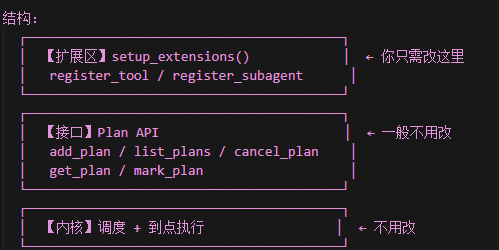

1. 自己写 @tool / 子 Agent，register 后 plans.build()  
2. 对话 Agent 从自然语言自己生成「时间 + 任务」参数，调用工具写入计划清单  
3. 自然语言或代码取消；计划跑完后线程自动退出  

plans.register_tool(my_tool)  
plans.build()  

config = {"configurable": {"thread_id": "001"}}  
chat_stream([HumanMessage(content="每1分钟监测天气")], config)  
plans.status()  
plans.stop(title="监测天气")  

In [5]:
import calendar
import threading
import time
import uuid
from datetime import datetime, timedelta
from typing import Any, Callable

from langchain.tools import tool  
from langgraph.checkpoint.memory import InMemorySaver, MemorySaver

In [6]:
class PlanService:

    """
    计划清单服务。方法按四类组织，调用示例：

    ---- 1. 能力注入 ----
        plans.register_tool(get_weather)
        plans.register_subagent({"name": "...", "description": "...",
                                 "system_prompt": "...", "tools": [...]})
        plans.build()                          # 注册完调用一次
        plans.build(with_manager=True)         # 额外建内置管理 Agent（少用）

    ---- 2. 子智能体初始化 ----
        plans.subagent_spec()
        plans.subagent_spec(name="x", description="...", system_prompt="...")
        create_deep_agent(..., subagents=[plans.subagent_spec()])
        plans.agent                            # 仅 with_manager=True 后可用

    ---- 3. 计划管理 ----
        plans.add("标题", "任务内容", "interval", interval_minutes=1, max_runs=3)
        plans.add("标题", "内容", "periodic", period="daily", hour=20, minute=0)
        plans.add("标题", "内容", "once", run_at="2026-07-30 08:00:00")
        plans.list_plans() / plans.list_plans(include_done=False)
        plans.get("a1b2c3d4")
        text = plans.show()
        rows = plans.status() / plans.status(plan_id="a1b2c3d4")
        plans.stop(plan_id="...") / plans.stop(title="...")
        n = plans.stop_all()

    ---- 4. 人机交互 ----
        info = plans.keep_alive()              # Ctrl+C → stop_all
        info = plans.keep_alive(until_idle=True)
    """

    ACTIVE = frozenset({"pending", "in_progress"})
    DONE = frozenset({"completed", "cancelled"})

    def __init__(self, llm):
        self.llm = llm
        self._tools: list = []
        self._subagents: list = []
        self._runner = None
        self._agent = None
        self._plans: dict[str, dict] = {}
        self._lock = threading.Lock()
        self._checkpointer = InMemorySaver()

    # =========================================================================
    # 1. 能力注入：注册到点执行用的 tool / 子 Agent，并 build 执行器
    # =========================================================================

    def register_tool(self, t):
        self._tools.append(t)
        return t

    def register_subagent(self, cfg: dict):
        self._subagents.append(cfg)
        return cfg

    def build(self, *, with_manager: bool = False):
        self._runner = create_deep_agent(
            model=self.llm,
            tools=list(self._tools),
            subagents=list(self._subagents) or None,
            system_prompt=(
                "你是计划执行器。到点只完成本轮任务一次；用工具/子 Agent；"
                "勿讨论调度；简洁中文，勿编造数值。"
            ),
        )
        if with_manager:
            cfg = self.subagent_spec()
            self._agent = create_deep_agent(
                model=self.llm,
                tools=cfg["tools"],
                checkpointer=self._checkpointer,
                system_prompt=cfg["system_prompt"],
            )
        else:
            self._agent = None
        return self

    # =========================================================================
    # 2. 子智能体初始化：导出规格供主 Agent 挂载；可选内置管理 Agent
    # =========================================================================

    @property
    def agent(self):
        if self._agent is None:
            raise RuntimeError("请用 plans.subagent_spec() 挂主 Agent，或 build(with_manager=True)")
        return self._agent

    def subagent_spec(
        self,
        *,
        name: str = "scheduled_plan_agent",
        description: str | None = None,
        system_prompt: str | None = None,
    ) -> dict:
        return {
            "name": name,
            "description": description
            or "负责定时/预约计划的创建、查询与终止。提到定时任务或计划清单时调用。",
            "system_prompt": system_prompt
            or (
                f"你是计划调度专家。当前：{datetime.now().strftime('%Y-%m-%d %A %H:%M')}。\n"
                "按意图调用工具：\n"
                "- 创建 → create_scheduled_task"
                "（title/content；schedule_type=interval|periodic|once；"
                "interval→interval_minutes；periodic→period+hour/minute；once→run_at）\n"
                "- 查询 → list_scheduled_tasks\n"
                "- 终止 → stop_scheduled_task\n"
                "计划后台执行，建单后简短确认。"
            ),
            "tools": self._make_manage_tools(),
        }

    def _make_manage_tools(self):
        """子智能体工具：自然语言 → add / status / stop。"""
        svc = self

        @tool
        def create_scheduled_task(
            title: str,
            content: str,
            schedule_type: str,
            schedule_desc: str = "",
            interval_minutes: float = 0,
            period: str = "",
            weekday: int = -1,
            day_of_month: int = -1,
            hour: int = 0,
            minute: int = 0,
            run_at: str = "",
            max_runs: int = 0,
        ) -> str:
            """创建定时计划。schedule_type: interval|periodic|once。"""
            try:
                plan = svc.add(
                    title=title,
                    content=content,
                    schedule_type=schedule_type,
                    schedule_desc=schedule_desc,
                    interval_minutes=interval_minutes,
                    period=period,
                    weekday=weekday,
                    day_of_month=day_of_month,
                    hour=hour,
                    minute=minute,
                    run_at=run_at,
                    max_runs=max_runs,
                )
            except Exception as e:
                return f"创建失败：{e}"
            return (
                f"已启动 [{plan['id']}] {plan['title']} | "
                f"{plan.get('schedule_desc')} | {plan['content']}"
            )

        @tool
        def list_scheduled_tasks() -> str:
            """查询计划列表。"""
            rows = svc.status()
            if not rows:
                return "计划清单为空。"
            return svc._format_rows(rows, with_thread=True)

        @tool
        def stop_scheduled_task(plan_id: str = "", title: str = "") -> str:
            """终止计划（title 或 plan_id）。"""
            ok = svc.stop(plan_id=plan_id, title=title)
            key = plan_id or title
            if not ok:
                return f"未找到：{key}"
            return f"已终止：{key}\n{svc._format_rows(svc.status(), with_thread=True)}"

        return [create_scheduled_task, list_scheduled_tasks, stop_scheduled_task]

    # =========================================================================
    # 3. 计划管理：增删查、进程状态、后台调度内核
    # =========================================================================

    def add(
        self,
        title: str,
        content: str,
        schedule_type: str,
        *,
        interval_minutes: float = 0,
        period: str = "",
        weekday: int = -1,
        day_of_month: int = -1,
        hour: int = 0,
        minute: int = 0,
        run_at: str = "",
        max_runs: int = 0,
        schedule_desc: str = "",
    ) -> dict:
        st = (schedule_type or "").strip().lower()
        plan_id = uuid.uuid4().hex[:8]
        plan = {
            "id": plan_id,
            "title": title or "未命名计划",
            "content": content or title or "",
            "status": "pending",
            "schedule_type": st,
            "schedule": {
                "interval_minutes": interval_minutes,
                "period": period,
                "weekday": weekday,
                "day_of_month": day_of_month,
                "hour": hour,
                "minute": minute,
                "run_at": run_at,
            },
            "schedule_desc": schedule_desc or st,
            "max_runs": max_runs,
            "run_count": 0,
            "next_run": run_at if st == "once" and run_at else "-",
            "last_result": "",
            "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "_stop": threading.Event(),
        }
        with self._lock:
            self._plans[plan_id] = plan
        th = threading.Thread(
            target=self._loop, args=(plan_id,), daemon=False, name=f"plan-{plan_id}"
        )
        plan["_thread"] = th
        th.start()
        return self._public(plan)

    def list_plans(self, include_done: bool = True) -> list[dict]:
        with self._lock:
            items = list(self._plans.values())
        if not include_done:
            items = [p for p in items if p["status"] in self.ACTIVE]
        return [self._public(p) for p in items]

    def get(self, plan_id: str) -> dict | None:
        with self._lock:
            p = self._plans.get(plan_id)
        return self._public(p) if p else None

    def show(self) -> str:
        """返回计划清单可读文本（不含线程信息）。"""
        return self._format_rows(self.list_plans())

    def status(self, plan_id: str = "") -> list[dict]:
        """返回计划进程数据（含 thread_alive）；不打印。"""
        with self._lock:
            raw = (
                [self._plans[plan_id]]
                if plan_id and plan_id in self._plans
                else list(self._plans.values())
            )
        rows = []
        for p in raw:
            th = p.get("_thread")
            rows.append({
                **self._public(p),
                "thread_name": th.name if th else None,
                "thread_alive": bool(th and th.is_alive()),
            })
        return rows

    def stop(self, plan_id: str = "", title: str = "") -> bool:
        if not plan_id and title:
            for p in self.list_plans():
                if title in p["title"] or title in p["content"]:
                    plan_id = p["id"]
                    break
        if not plan_id:
            return False
        with self._lock:
            p = self._plans.get(plan_id)
            if not p:
                return False
            p["_stop"].set()
            p["status"] = "cancelled"
            th = p.get("_thread")
        if th and th.is_alive() and th is not threading.current_thread():
            th.join(timeout=2)
        return True

    def stop_all(self) -> int:
        return sum(1 for p in self.list_plans(include_done=False) if self.stop(plan_id=p["id"]))

    @staticmethod
    def _public(p: dict) -> dict:
        return {k: v for k, v in p.items() if not k.startswith("_")}

    @staticmethod
    def _format_rows(rows: list[dict], *, with_thread: bool = False) -> str:
        if not rows:
            return "（空）"
        lines = []
        for i, r in enumerate(rows, 1):
            line = (
                f"{i}. [{r['status']}] {r['title']} ({r['id']}) | "
                f"{r.get('schedule_desc') or r.get('schedule_type')} | "
                f"下次{r.get('next_run')} | 已执行{r.get('run_count', 0)} | "
                f"{r.get('content', '')}"
            )
            if with_thread:
                alive = "运行中" if r.get("thread_alive") else "已结束"
                line += f" | 线程={r.get('thread_name')}({alive})"
            lines.append(line)
        return "\n".join(lines)

    def _next_time(self, p: dict, after: datetime) -> datetime | None:
        st, s = p["schedule_type"], p["schedule"]
        try:
            if st == "interval":
                mins = float(s.get("interval_minutes") or 0)
                return after + timedelta(minutes=mins) if mins > 0 else None
            if st == "periodic":
                hour, minute = int(s.get("hour") or 0), int(s.get("minute") or 0)
                period = s.get("period") or ""
                if period == "daily":
                    t = after.replace(hour=hour, minute=minute, second=0, microsecond=0)
                    return t if t > after else t + timedelta(days=1)
                if period == "weekly":
                    days = (int(s.get("weekday") or 0) - after.weekday()) % 7
                    t = (after + timedelta(days=days)).replace(
                        hour=hour, minute=minute, second=0, microsecond=0
                    )
                    return t if t > after else t + timedelta(days=7)
                if period == "monthly":
                    day = int(s.get("day_of_month") or 1)
                    y, m = after.year, after.month

                    def _at(yy, mm):
                        d = min(day, calendar.monthrange(yy, mm)[1])
                        return datetime(yy, mm, d, hour, minute)

                    t = _at(y, m)
                    if t <= after:
                        y, m = (y + 1, 1) if m == 12 else (y, m + 1)
                        t = _at(y, m)
                    return t
            if st == "once":
                run_at = s.get("run_at") or ""
                if not run_at:
                    return None
                t = datetime.strptime(run_at, "%Y-%m-%d %H:%M:%S")
                return t if t > after else None
        except Exception:
            return None
        return None

    def _execute(self, p: dict) -> str:
        if self._runner is None:
            return "执行器未初始化，请先 plans.build()"
        result = self._runner.invoke({
            "messages": [HumanMessage(
                content=(
                    f"当前时间：{datetime.now():%Y-%m-%d %H:%M:%S}\n"
                    f"计划标题：{p['title']}\n请完成：{p['content']}"
                )
            )]
        })
        for msg in reversed(result.get("messages", [])):
            if getattr(msg, "type", None) == "ai" and msg.content:
                return msg.content
        return ""

    def _loop(self, plan_id: str) -> None:
        with self._lock:
            p = self._plans.get(plan_id)
        if not p:
            return
        try:
            first = p["schedule_type"] == "interval"
            while not p["_stop"].is_set():
                if first:
                    first = False
                else:
                    nxt = self._next_time(p, datetime.now())
                    if nxt is None:
                        break
                    with self._lock:
                        p["next_run"] = nxt.strftime("%Y-%m-%d %H:%M:%S")
                        p["status"] = "pending"
                    wait = (nxt - datetime.now()).total_seconds()
                    if wait > 0 and p["_stop"].wait(wait):
                        break

                with self._lock:
                    if p["status"] == "cancelled":
                        break
                    p["status"] = "in_progress"
                    p["run_count"] += 1

                try:
                    answer = self._execute(p)
                    with self._lock:
                        p["last_result"] = answer
                except Exception as e:
                    with self._lock:
                        p["last_result"] = f"错误: {e}"

                done = p["schedule_type"] == "once" or (
                    p["max_runs"] > 0 and p["run_count"] >= p["max_runs"]
                )
                with self._lock:
                    if p["status"] == "cancelled":
                        break
                    p["status"] = "completed" if done else "pending"
                if done:
                    break
        finally:
            with self._lock:
                if p.get("status") not in self.DONE:
                    p["status"] = "cancelled" if p["_stop"].is_set() else "completed"
                p["_thread"] = None

    # =========================================================================
    # 4. 人机交互：脚本保活（Web/交互循环一般不需要）
    # =========================================================================

    def keep_alive(self, until_idle: bool = False) -> dict:
        """
        阻塞保活。结束时返回摘要 dict：
          {"reason": "idle"|"interrupt", "stopped": int, "plans": list}
        """
        try:
            while True:
                if until_idle and not any(
                    p["status"] in self.ACTIVE for p in self.list_plans()
                ):
                    return {"reason": "idle", "stopped": 0, "plans": self.status()}
                time.sleep(1)
        except KeyboardInterrupt:
            n = self.stop_all()
            return {"reason": "interrupt", "stopped": n, "plans": self.status()}


In [7]:
plans = PlanService(llm)
plans.build()
plans_agnet = plans.subagent_spec()

# 子智能体与功能

In [8]:
import requests

@tool
def get_weather(longitude: str, latitude: str):
    '''
    功能:使用Open-Meteo查询指定坐标的天气情况。
    Args:
        longitude:经度，例如 "52.520011"
        latitude:纬度，例如 "13.410004"
    return:
        指定坐标未来逐小时的温度和相对湿度摘要。
    '''
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "hourly": "temperature_2m,relative_humidity_2m",
        "timezone": "auto",
        "forecast_days": 3
    }
    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()
        return data
    except requests.exceptions.RequestException as e:
        return f"天气接口请求失败：{str(e)}"
    print('执行get_weather完成')


plans.register_tool(get_weather)
plans.build()

In [9]:
weather_agent = {
    "name": "weather_agent",
    "description": "查询指定坐标天气，并总结温度、湿度变化趋势",
    "system_prompt": "你是一个气象专家，必须先调用 get_weather 获取数据，再用简洁中文总结温度、湿度范围。禁止编造数值。",
    "tools": [get_weather]
}
plans.register_subagent(weather_agent)
plans.build()  

# 主智能体

In [10]:
agent = create_deep_agent(
    model=llm,
    system_prompt='你是一名柑橘产业农业智能助手',
    subagents=[plans_agnet],
    checkpointer=MemorySaver()
)

In [11]:
config = {"configurable": {"thread_id": "demo-001"}}

In [12]:
text = "启动定时任务，每1分钟查询武汉天气情况"
chat_stream(agent, llm, build_msg(text=text), config)

[主Agent] 请求调用: ['task']
-------------------------------
[tools:dfd9f689-3b35-d6df-ea86-59eff507daa7] 请求调用: ['create_scheduled_task']
-------------------------------
[tools:dfd9f689-3b35-d6df-ea86-59eff507daa7] [调用工具 create_scheduled_task]
[tools:dfd9f689-3b35-d6df-ea86-59eff507daa7] [tool] 已启动 [d97e379a] 武汉天气查询 | interval | 查询武汉天气情况
-------------------------------
[tools:dfd9f689-3b35-d6df-ea86-59eff507daa7] [ai] ✅ 定时任务创建成功！

**任务信息：**
- **任务ID**: d97e379a
- **任务名称**: 武汉天气查询
- **执行频率**: 每 1 分钟执行一次（interval）
- **任务内容**: 查询武汉天气情况
- **目标城市**: 武汉
- **状态**: 已启动

任务已在后台运行，将每隔 1 分钟自动执行武汉天气查询。
-------------------------------
[主Agent] [调用工具 task]
[主Agent] [tool] ✅ 定时任务创建成功！

**任务信息：**
- **任务ID**: d97e379a
- **任务名称**: 武汉天气查询
- **执行频率**: 每 1 分钟执行一次（interval）
- **任务内容**: 查询武汉天气情况
- **目标城市**: 武汉
- **状态**: 已启动

任务已在后台运行，将每隔 1 分钟自动执行武汉天气查询。
-------------------------------
[主Agent] [ai] ✅ 定时任务已成功启动！

**任务详情：**
- **任务ID**: d97e379a
- **任务名称**: 武汉天气查询
- **执行频率**: 每 1 分钟
- **目标城市**: 武汉
- **状态**: 运行中

系统将

In [13]:
text = "你是谁"
chat_stream(agent, llm, build_msg(text=text), config)

[主Agent] [ai] 我是柑橘产业农业智能助手，专注于为柑橘种植、管理、病虫害防治、市场分析等提供专业农业咨询服务。

同时我也具备定时任务管理能力，可以帮您设置周期性查询（如刚才的武汉天气查询）。

有什么可以帮您的吗？
-------------------------------


In [14]:
print("------------查询计划列表完成---------------")
print("list_plans():", plans.list_plans())

------------查询计划列表完成---------------
list_plans(): [{'id': 'd97e379a', 'title': '武汉天气查询', 'content': '查询武汉天气情况', 'status': 'in_progress', 'schedule_type': 'interval', 'schedule': {'interval_minutes': 1.0, 'period': '', 'weekday': -1, 'day_of_month': -1, 'hour': 0, 'minute': 0, 'run_at': ''}, 'schedule_desc': 'interval', 'max_runs': 0, 'run_count': 1, 'next_run': '-', 'last_result': '', 'created_at': '2026-07-29 14:12:32'}]


In [15]:
print("show:\n", plans.show())
print("status():\n", plans.status())

show:
 1. [in_progress] 武汉天气查询 (d97e379a) | interval | 下次- | 已执行1 | 查询武汉天气情况
status():
 [{'id': 'd97e379a', 'title': '武汉天气查询', 'content': '查询武汉天气情况', 'status': 'in_progress', 'schedule_type': 'interval', 'schedule': {'interval_minutes': 1.0, 'period': '', 'weekday': -1, 'day_of_month': -1, 'hour': 0, 'minute': 0, 'run_at': ''}, 'schedule_desc': 'interval', 'max_runs': 0, 'run_count': 1, 'next_run': '-', 'last_result': '', 'created_at': '2026-07-29 14:12:32', 'thread_name': 'plan-d97e379a', 'thread_alive': True}]


In [18]:
print(plans.status())
text = "查询执行中的计划"
chat_stream(agent, llm, build_msg(text=text), config)

[{'id': 'd97e379a', 'title': '武汉天气查询', 'content': '查询武汉天气情况', 'status': 'cancelled', 'schedule_type': 'interval', 'schedule': {'interval_minutes': 1.0, 'period': '', 'weekday': -1, 'day_of_month': -1, 'hour': 0, 'minute': 0, 'run_at': ''}, 'schedule_desc': 'interval', 'max_runs': 0, 'run_count': 3, 'next_run': '2026-07-29 14:17:06', 'last_result': '## 武汉天气情况\n\n**当前位置**：纬度 30.62°，经度 114.28°，海拔 15 米\n\n### 今日（7 月 29 日）天气\n- **当前温度**：约 31°C（14 时）\n- **今日温度范围**：25.9°C ~ 31.7°C\n- **当前湿度**：约 66%\n- **今日湿度范围**：64% ~ 95%\n\n### 未来三天趋势\n\n| 日期 | 最低温 | 最高温 | 湿度范围 |\n|------|--------|--------|----------|\n| 7/29 | 25.9°C | 31.7°C | 64%~95% |\n| 7/30 | 27.4°C | 32.3°C | 63%~86% |\n| 7/31 | 27.6°C | 32.6°C | 62%~83% |\n\n### 变化趋势\n- **温度**：逐日小幅上升，白天高温时段集中在 14:00-16:00\n- **湿度**：逐日略有下降，夜间至清晨湿度较高（80%~95%），午后最低（62%~67%）\n\n整体天气炎热潮湿，建议注意防暑降温。', 'created_at': '2026-07-29 14:12:32', 'thread_name': None, 'thread_alive': False}]
[主Agent] 请求调用: ['task']
-------------------------------
[tools:bc073a5d-a3bd

# 进阶设想
计划主表（plans）：固化调度定义与运行态（内容、策略、次数、下次触发、启用标志等），作为「可再启动」的权威配置。  
执行流水表（plan_runs）：记录每一次执行的起止、成败与结果文本，支撑审计、复盘与「最新一次响应」查询。  

选中续跑（Select & Continue）
用户从库中选定既有计划（或输入 id/标题），智能体据此：  
·恢复调度（resume）：按原调度策略重新挂载后台循环；或  
·立即执行一轮（run_now）：在不改变/按需调整调度时钟的前提下触发一次执行并落库。  

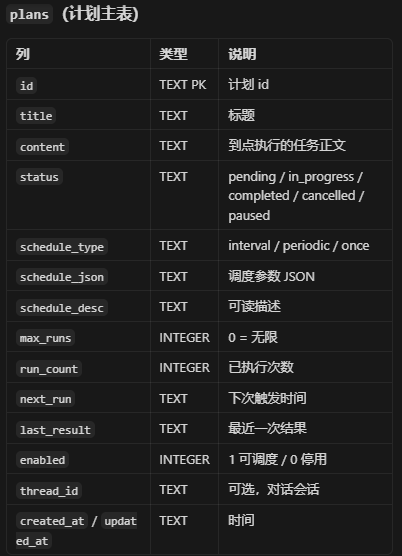
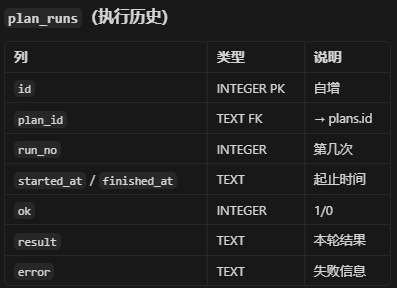

In [ ]:
"""
MySQL 计划清单建表脚本。

修改下方 MYSQL_* 参数后运行：
    python database.py
将自动创建数据库（若不存在）及 plans / plan_runs 两张表。
依赖：pip install pymysql
"""

import uuid

import pymysql

# =============================================================================
# 连接参数（按环境修改）
# =============================================================================

MYSQL_HOST = "127.0.0.1"
MYSQL_PORT = 3306
MYSQL_USER = "root"
MYSQL_PASSWORD = "your_password"
MYSQL_DATABASE = "agent_plans"
MYSQL_CHARSET = "utf8mb4"

# =============================================================================
# DDL
# =============================================================================

DDL_PLANS = """
CREATE TABLE IF NOT EXISTS plans (
    id              VARCHAR(32)  NOT NULL COMMENT '命名规则 plan_<16位hex>，如 plan_a1b2c3d4e5f67890',
    title           VARCHAR(255) NOT NULL DEFAULT '' COMMENT '标题',
    content         TEXT         NOT NULL COMMENT '到点执行任务正文',
    status          VARCHAR(32)  NOT NULL DEFAULT 'pending'
                    COMMENT 'pending/in_progress/completed/cancelled/paused',
    schedule_type   VARCHAR(32)  NOT NULL DEFAULT ''
                    COMMENT 'interval/periodic/once',
    schedule_json   TEXT         NULL
                    COMMENT '调度参数JSON: interval_minutes,period,weekday,day_of_month,hour,minute,run_at',
    schedule_desc   VARCHAR(255) NOT NULL DEFAULT '' COMMENT '可读调度描述',
    max_runs        INT          NOT NULL DEFAULT 0 COMMENT '最大次数，0=无限',
    run_count       INT          NOT NULL DEFAULT 0 COMMENT '已执行次数',
    next_run        VARCHAR(32)  NOT NULL DEFAULT '-' COMMENT '下次触发时间',
    last_result     MEDIUMTEXT   NULL COMMENT '最近一次结果摘要',
    enabled         TINYINT      NOT NULL DEFAULT 1 COMMENT '1可调度/0停用',
    thread_id       VARCHAR(128) NULL COMMENT '可选，对话会话 id',
    created_at      VARCHAR(32)  NOT NULL DEFAULT '' COMMENT '创建时间',
    updated_at      VARCHAR(32)  NOT NULL DEFAULT '' COMMENT '最后更新时间',
    PRIMARY KEY (id),
    KEY idx_plans_status (status),
    KEY idx_plans_title (title),
    KEY idx_plans_enabled (enabled)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4 COMMENT='计划主表';
"""

DDL_PLAN_RUNS = """
CREATE TABLE IF NOT EXISTS plan_runs (
    id           VARCHAR(32)  NOT NULL COMMENT '命名规则 run_<16位hex>，如 run_9f8e7d6c5b4a3210',
    plan_id      VARCHAR(32)  NOT NULL COMMENT '关联 plans.id，同为 plan_<16位hex>',
    run_no       INT          NOT NULL COMMENT '第几次执行',
    started_at   VARCHAR(32)  NOT NULL DEFAULT '' COMMENT '开始时间',
    finished_at  VARCHAR(32)  NOT NULL DEFAULT '' COMMENT '结束时间',
    ok           TINYINT      NOT NULL DEFAULT 1 COMMENT '1成功/0失败',
    result       MEDIUMTEXT   NULL COMMENT '本轮执行结果',
    error        TEXT         NULL COMMENT '失败信息',
    PRIMARY KEY (id),
    UNIQUE KEY uk_plan_runs_plan_no (plan_id, run_no),
    KEY idx_plan_runs_plan_id (plan_id),
    CONSTRAINT fk_plan_runs_plan
        FOREIGN KEY (plan_id) REFERENCES plans (id)
        ON DELETE CASCADE ON UPDATE CASCADE
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4 COMMENT='计划执行历史';
"""


def _hex16() -> str:
    return uuid.uuid4().hex[:16]


def new_plan_id() -> str:
    """计划 id：plan_<16位hex>，如 plan_a1b2c3d4e5f67890。"""
    return f"plan_{_hex16()}"


def new_run_id() -> str:
    """执行记录 id：run_<16位hex>，如 run_9f8e7d6c5b4a3210。"""
    return f"run_{_hex16()}"


def get_connection(*, with_database: bool = True):
    kwargs = dict(
        host=MYSQL_HOST,
        port=MYSQL_PORT,
        user=MYSQL_USER,
        password=MYSQL_PASSWORD,
        charset=MYSQL_CHARSET,
        autocommit=True,
    )
    if with_database:
        kwargs["database"] = MYSQL_DATABASE
    return pymysql.connect(**kwargs)


def ensure_database() -> None:
    conn = get_connection(with_database=False)
    try:
        with conn.cursor() as cur:
            cur.execute(
                f"CREATE DATABASE IF NOT EXISTS `{MYSQL_DATABASE}` "
                f"DEFAULT CHARACTER SET {MYSQL_CHARSET} "
                f"COLLATE {MYSQL_CHARSET}_unicode_ci"
            )
        print(f"[ok] database `{MYSQL_DATABASE}` ready")
    finally:
        conn.close()


def init_tables() -> None:
    conn = get_connection(with_database=True)
    try:
        with conn.cursor() as cur:
            cur.execute(DDL_PLANS)
            print("[ok] table `plans` ready")
            cur.execute(DDL_PLAN_RUNS)
            print("[ok] table `plan_runs` ready")
    finally:
        conn.close()


def init_db() -> None:
    ensure_database()
    init_tables()
    print(
        f"[done] {MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE} "
        f"— plans / plan_runs initialized"
    )


if __name__ == "__main__":
    init_db()
